<a href="https://colab.research.google.com/github/krmkalfa/rag-egitim/blob/main/3.B%C3%BCy%C3%BCk%20Dil%20Modellerine%20Eri%C5%9Fim/3_Gemini_Yaz%C4%B1l%C4%B1m_Geli%C5%9Ftirme_Kiti_(SDK).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Copyright 2025 Murat Karakaya



In [ ]:
# @title Apache Lisansı, Sürüm 2.0 (bu "Lisans") altında lisanslanmıştır;
#
# Apache Lisansı, Sürüm 2.0 ("Lisans") altında lisanslanmıştır;
# bu dosyayı Lisans'a uymadan kullanamazsınız.
# MUrat Karakaya tarafından [İngilizce versiyonundan](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb)
# genişletilip geliştirilmiştir.
#
# Lisans'ın bir kopyasını şu adresten edinebilirsiniz:
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Yürürlükteki yasalarca gerekmedikçe veya yazılı olarak kabul edilmedikçe,
# Lisans altında dağıtılan yazılım "OLDUĞU GİBİ",
# AÇIK VEYA ZIMNİ GARANTİLER VEYA KOŞULLAR OLMAKSIZIN dağıtılır.
# Lisans kapsamında belirli bir dil için geçerli olan izinleri ve
# sınırlamaları görmek için Lisans'a bakın.

## Gemini API: Gemini Modelleriyle Başlangıç

Yeni **Google Gen AI Yazılım Geliştirme Kiti (SDK)**, hem Gemini Geliştirici (Developer) API'si hem de Vertex AI üzerindeki Gemini API'si aracılığıyla Gemini modellerine birleşik bir arayüz sağlar. Birkaç istisna dışında, bir platformda çalışan kod her ikisinde de çalışacaktır. Bu not defteri Geliştirici API'sini kullanır.

Bu not defteri size şunları adım adım gösterecektir:

*   Google GenAI SDK'yı Yükleme ve Kurulumu
*   Metin ve çok modlu istemler
*   Tokenları sayma
*   Sistem talimatlarını ayarlama
*   Güvenlik filtrelerini yapılandırma
*   Çok turlu bir sohbet başlatma
*   Üretilen çıktıyı kontrol etme
*   Yapısal çıktı üretme
*   İçerik akışı oluşturma
*   Metin gömmeleri oluşturma

Bu yeni SDK hakkında daha fazla bilgiye not defterin sonundaki belgelerden ulaşabilirsiniz.

## Kurulum

### SDK'yı Yükle

SDK'yı [PyPI](https://github.com/googleapis/python-genai) 'dan yükleyin..

In [ ]:
%pip install -U -q 'google-genai>=1.0.0'

### API Anahtarınızı Kurun

Aşağıdaki hücreyi çalıştırmak için API anahtarınız `GOOGLE_API_KEY` adlı bir Colab Secret'ta saklanmalıdır. Halihazırda bir API anahtarınız yoksa veya bir Colab Secret'ı nasıl oluşturacağınızdan emin değilseniz, bir önceki bölümü izleyiniz.

In [ ]:
from google.colab import userdata

GOOGLE_API_KEY = userdata.get('GEMINI_API_KEY')

### SDK istemcisini başlat

Yeni SDK ile artık bir istemciyi API anahtarınızla başlatmanız yeterlidir. Model artık her çağrıda ayarlanır.

In [ ]:
from google import genai
from google.genai import types

client = genai.Client(api_key=GOOGLE_API_KEY)

## Metin Üretimi

### Bir model seçin

Bu kılavuzda kullanmak istediğiniz modeli seçin. Listeden birini seçebilir veya manuel olarak bir model adı girebilirsiniz. Bazı modellerin, örneğin 2.5 modellerinin düşünme modelleri olduğunu ve bu nedenle yanıt vermek için biraz daha fazla zaman aldığını unutmayın.

Tüm Gemini modellerinin tam bir genel görünümü için [belgelere](https://ai.google.dev/gemini-api/docs/models/gemini) göz atın.

In [ ]:
MODEL_ID = "gemini-2.0-flash"

### Metin yönlendirmelerini (prompt) gönderin



Yönlendirmelerinize yanıtlar oluşturmak için `generate_content` yöntemini kullanın. Metni doğrudan `generate_content`'a iletebilir ve yanıtın metin içeriğini almak için `.text` özelliğini kullanabilirsiniz. `.text` alanının, çıktıda yalnızca tek bir bölüm olduğunda çalışacağını unutmayın.

In [ ]:
user_prompt="2025 yılında Türkiye'nin en az nüfuslu ili hangisidir?"

In [ ]:
from IPython.display import Markdown

response = client.models.generate_content(
    model=MODEL_ID,
    contents=user_prompt
)

In [ ]:
print(response.text)

Türkiye İstatistik Kurumu (TÜİK) henüz 2025 yılı nüfus projeksiyonlarını yayımlamadığı için 2025 yılında Türkiye'nin en az nüfuslu ilinin hangisi olacağını kesin olarak söylemek mümkün değil.

Ancak, son yıllardaki nüfus değişimleri ve trendler dikkate alındığında, **Tunceli**'nin en az nüfuslu il olma eğiliminin devam etmesi beklenmektedir. Tunceli, uzun yıllardır Türkiye'nin en az nüfuslu ili konumunda ve bu durumun kısa vadede değişmesi öngörülmüyor.

Yine de, TÜİK'in 2025 yılı nüfus projeksiyonlarını yayımlamasıyla birlikte kesin bilgiye ulaşılabilir.



In [ ]:
Markdown(response.text)

Türkiye İstatistik Kurumu (TÜİK) henüz 2025 yılı nüfus projeksiyonlarını yayımlamadığı için 2025 yılında Türkiye'nin en az nüfuslu ilinin hangisi olacağını kesin olarak söylemek mümkün değil.

Ancak, son yıllardaki nüfus değişimleri ve trendler dikkate alındığında, **Tunceli**'nin en az nüfuslu il olma eğiliminin devam etmesi beklenmektedir. Tunceli, uzun yıllardır Türkiye'nin en az nüfuslu ili konumunda ve bu durumun kısa vadede değişmesi öngörülmüyor.

Yine de, TÜİK'in 2025 yılı nüfus projeksiyonlarını yayımlamasıyla birlikte kesin bilgiye ulaşılabilir.


In [ ]:
print(response)

sdk_http_response=HttpResponse(
  headers=<dict len=10>
) candidates=[Candidate(
  avg_logprobs=-0.12985072615583973,
  content=Content(
    parts=[
      Part(
        text="""Türkiye İstatistik Kurumu (TÜİK) henüz 2025 yılı nüfus projeksiyonlarını yayımlamadığı için 2025 yılında Türkiye'nin en az nüfuslu ilinin hangisi olacağını kesin olarak söylemek mümkün değil.

Ancak, son yıllardaki nüfus değişimleri ve trendler dikkate alındığında, **Tunceli**'nin en az nüfuslu il olma eğiliminin devam etmesi beklenmektedir. Tunceli, uzun yıllardır Türkiye'nin en az nüfuslu ili konumunda ve bu durumun kısa vadede değişmesi öngörülmüyor.

Yine de, TÜİK'in 2025 yılı nüfus projeksiyonlarını yayımlamasıyla birlikte kesin bilgiye ulaşılabilir.
"""
      ),
    ],
    role='model'
  ),
  finish_reason=<FinishReason.STOP: 'STOP'>
)] create_time=None response_id=None model_version='gemini-2.0-flash' prompt_feedback=None usage_metadata=GenerateContentResponseUsageMetadata(
  candidates_token_count=169,
 

### Gemini'den Gelen Cevabı (Response) İnceleyin



Gemini'ye bir soru sorduğunuzda, size sadece cevabı göndermez; cevabın nasıl oluşturulduğuna dair tüm detayları içeren zengin bir "bilgi paketi" yollar. İşte bu paket `GenerateContentResponse` nesnesidir. Gelin bu paketin içindeki en önemli parçaları birlikte inceleyelim.

Bunu, size gelen bir kargo paketi gibi düşünebilirsiniz:

---

#### 1. Paketin İçindeki Asıl Ürün: `candidates`

Bu, en çok ilgilendiğiniz kısımdır: Modelin sizin için ürettiği **cevabın kendisi**.

*   **Neden bir liste (`[]`) içinde?** Model teorik olarak aynı soruya birden fazla cevap alternatifi üretebilir. Ancak genellikle tek ve en iyi cevabı alırsınız.
*   **Cevabı nasıl alırsınız?** İlk ve genelde tek olan cevabın metnine ulaşmak için:
    `response.candidates[0].content.parts[0].text`

> **Özetle:** Burası, modelin "2025 yılında Türkiye'nin en az nüfuslu ili..." diye başlayan asıl metninin bulunduğu yerdir.

---

#### 2. Kullanım Faturası: `usage_metadata`

Bu bölüm, yaptığınız isteğin size "maliyetini" token cinsinden gösterir. API kullanımınızı takip etmek ve faturalandırmayı anlamak için en önemli kısımdır.

*   `prompt_token_count` (Giriş Maliyeti): Sizin sorduğunuz sorunun token sayısı. (Örnek: 19)
*   `candidates_token_count` (Cevap Maliyeti): Modelin ürettiği cevabın token sayısı. (Örnek: 140)
*   `thoughts_token_count` (Düşünme Maliyeti): **Bu çok önemli!** Modelin cevabı bulmak için arka planda yaptığı düşünme, planlama ve ara hesaplamaların maliyetidir. Bunu, modelin cevabı yazmadan önce kullandığı bir "karalama kağıdı" gibi düşünebilirsiniz. (Örnek: 992)
*   `total_token_count` (Toplam Maliyet): Yukarıdakilerin hepsinin toplamıdır. Bu yüzden toplam token sayısı, sadece soru ve cevabın toplamından daha fazladır! (Örnek: 1151)

> **Özetle:** Bu bölüm, isteğinizin ne kadar "pahalı" olduğunu anlamanızı sağlar.

---

#### 3. Cevabın Durumu: `finish_reason`

Modelin cevabı neden ve nasıl sonlandırdığını belirtir. Bu, cevabın sağlıklı bir şekilde tamamlanıp tamamlanmadığını kontrol etmek için kritiktir.

*   `STOP`: Her şey yolunda. Model söyleyeceklerini bitirdi ve doğal bir şekilde durdu. (En sık görülen durum)
*   `MAX_TOKENS`: Cevap çok uzundu ve izin verilen maksimum token limitine ulaştığı için kesildi. Cevabın sonu eksik olabilir.
*   `FUNCTION_CALL`: Model, işleme devam etmek için sizin tanımladığınız bir fonksiyonu (tool) çağırması gerektiğini belirtiyor.

> **Özetle:** Cevabın yarım kalıp kalmadığını veya başka bir eylem gerekip gerekmediğini buradan anlarsınız.

---

#### 4. Diğer Bilgiler

*   **`model_version` (Model Etiketi):** Cevabı hangi Gemini modelinin ürettiğini gösteren basit bir bilgi. (Örnek: "gemini-2.5-flash")
*   **`sdk_http_response` (Teknik Kargo Bilgisi):** Genellikle hata ayıklama için kullanılır. API isteğinin sunucuya ulaşıp ulaşmadığı (HTTP 200 OK gibi durum kodları) ve diğer ağ seviyesi teknik bilgileri içerir.

---

### Genel Bakış

Kısacası, `GenerateContentResponse` sadece çıplak bir metin değil; **cevabın kendisi (`candidates`)**, bu cevabın **maliyeti (`usage_metadata`)** ve **nasıl tamamlandığı (`finish_reason`)** gibi hayati bilgileri bir arada sunan, geliştiriciler için tasarlanmış eksiksiz bir rapordur.

## Maliyeti Hesabı

### Neden LLM Maliyet Hesabı Yapmalıyız?

Büyük Dil Modeli (BDM-LLM) tabanlı kod yazarken maliyet hesabı yapmak çok önemlidir, çünkü:

1.  **Kullandıkça Öde Modeli:** Her BDM çağrısı (sorunuz ve modelin cevabı), "token" adı verilen birimler üzerinden doğrudan ücrete tabidir.
2.  **Beklenmedik Faturalar:** Geliştirme sürecindeki testler veya artan kullanıcı trafiği, token kullanımını ve dolayısıyla maliyetleri hızla artırabilir. Hesaplama yaparak sürpriz faturaların önüne geçersiniz.
3.  **Bütçeleme ve Optimizasyon:** Proje bütçenizi doğru planlamanıza ve performansı düşürmeden maliyetleri optimize etmenin (örneğin daha kısa promptlar veya farklı model seçenekleri) yollarını bulmanıza yardımcı olur.
4.  **Ölçeklenebilirlik:** Uygulamanız büyüdükçe ve kullanım arttıkça maliyetlerin nasıl seyredeceğini öngörmenizi ve finansal stratejinizi buna göre belirlemenizi sağlar.

Kısacası, LLM tabanlı geliştirmede her kullanımın bir maliyeti vardır ve bu maliyeti anlamak ve yönetmek, projenizin finansal sağlığı için hayati öneme sahiptir.

### Tokenları sayın



In [ ]:
try:
    usage_metadata = response.usage_metadata

    print("--- 🤖 Gemini API Token Maliyet Raporu ---")
    print(f"➡️  Girdi Token (Prompt)    : {usage_metadata.prompt_token_count}")
    print(f"⬅️  Çıktı Token (Cevap)      : {usage_metadata.candidates_token_count}")
    print(f"🧠  Düşünme Token (Arka Plan): {usage_metadata.thoughts_token_count}")
    print("-" * 40)
    print(f"💰  Toplam Faturalandırılan Token: {usage_metadata.total_token_count}")
    print("-" * 40)

except AttributeError:
    print("Hata: Yanıtta 'usage_metadata' bulunamadı. Yanıt yapısını veya isteğin başarılı olup olmadığını kontrol edin.")

--- 🤖 Gemini API Token Maliyet Raporu ---
➡️  Girdi Token (Prompt)    : 18
⬅️  Çıktı Token (Cevap)      : 169
🧠  Düşünme Token (Arka Plan): None
----------------------------------------
💰  Toplam Faturalandırılan Token: 187
----------------------------------------


### Maliyeti Hesaplayın

Gemini Developer API Fiyatlandırması için [bu bağlantıyı](https://ai.google.dev/gemini-api/docs/pricing?hl=tr) kullanabilirsiniz.

Ağustos 2025'de [Gemini 2.5 Flash modeli](https://ai.google.dev/gemini-api/docs/pricing?hl=tr#gemini-2.5-flash) için geçerli  1 milyon jeton başına ABD doları cinsinden
* Giriş fiyatı	Ücretsiz	0,30 ABD doları (metin / resim / video)

* Çıkış fiyatı (düşünme jetonları dahil)	Ücretsiz	2,50 ABD doları

BU verileri kullanarak toplam maliyet analizi yapabiliriz:

In [ ]:
# --- Gemini 2.5 Flash Fiyatlandırması (Ağustos 2025 için verilen) ---
# Fiyatlar 1 milyon token başına ABD doları cinsindendir.
INPUT_PRICE_PER_MILLION_TOKENS = 0.30  # Giriş fiyatı (metin / resim / video)
OUTPUT_PRICE_PER_MILLION_TOKENS = 2.50 # Çıkış fiyatı (düşünme jetonları dahil)

# 1 milyon token'a bölmek için kullanılacak çarpan
TOKENS_PER_MILLION = 1_000_000

try:
    usage_metadata = response.usage_metadata

    # --- Token Sayılarını Al ---
    girdi_token = usage_metadata.prompt_token_count
    cikti_token = usage_metadata.candidates_token_count
    dusunme_token = usage_metadata.thoughts_token_count
    toplam_faturalanan_token = usage_metadata.total_token_count
    # Bu, API'nin faturaladığı toplamdır.
    # Ancak maliyet hesaplamasında, girdi ve çıktı/düşünme ayrı ayrı ele alınır.

    # --- Maliyet Hesaplamaları ---
    # Giriş Maliyeti: Sadece prompt_token_count kullanılır.
    input_cost_usd = (girdi_token / TOKENS_PER_MILLION) * INPUT_PRICE_PER_MILLION_TOKENS

    # Çıkış Maliyeti: candidates_token_count ve thoughts_token_count birleşiktir.
    # Verilen fiyata göre "düşünme jetonları dahil" olduğu belirtilmiştir.
    # dusunme_token None olabilir, bu durumda 0 olarak alıyoruz.
    total_output_and_thought_tokens = cikti_token + (int(dusunme_token) if dusunme_token is not None else 0)
    output_cost_usd = (total_output_and_thought_tokens / TOKENS_PER_MILLION) * OUTPUT_PRICE_PER_MILLION_TOKENS

    # Toplam API Çağrı Maliyeti
    total_call_cost_usd = input_cost_usd + output_cost_usd

    # --- Sonuçları Ekrana Yazdırma ---
    print("--- 🤖 Gemini API Token Maliyet Raporu ---")
    print(f"➡️  Girdi Token (Prompt)    : {girdi_token} token")
    print(f"⬅️  Çıktı Token (Cevap)      : {cikti_token} token")
    print(f"🧠  Düşünme Token (Arka Plan): {dusunme_token} token") # None olsa bile None olarak yazdırıyoruz
    print("-" * 40)
    print(f"💰  API Tarafından Bildirilen Toplam Token: {toplam_faturalanan_token} token")
    print("-" * 40)
    print("\n--- 💲 ABD Doları Maliyet Analizi ---")
    print(f"💵 Giriş Maliyeti            : ${input_cost_usd:.8f}") # Formatlama ile daha fazla ondalık basamak gösteriyoruz
    print(f"💵 Çıkış + Düşünme Maliyeti  : ${output_cost_usd:.8f}")
    print("-" * 40)
    print(f"💸 TOPLAM ÇAĞRI MALİYETİ     : ${total_call_cost_usd:.8f}")
    print("-" * 40)

except AttributeError:
    print("Hata: 'usage_metadata' yanıtta bulunamadı. Yanıt yapısını veya isteğin başarılı olup olmadığını kontrol edin.")
    print("Eğer stream=True kullanıyorsanız, for döngüsü bittikten sonra bu koda eriştiğinizden emin olun.")

--- 🤖 Gemini API Token Maliyet Raporu ---
➡️  Girdi Token (Prompt)    : 18 token
⬅️  Çıktı Token (Cevap)      : 169 token
🧠  Düşünme Token (Arka Plan): None token
----------------------------------------
💰  API Tarafından Bildirilen Toplam Token: 187 token
----------------------------------------

--- 💲 ABD Doları Maliyet Analizi ---
💵 Giriş Maliyeti            : $0.00000540
💵 Çıkış + Düşünme Maliyeti  : $0.00042250
----------------------------------------
💸 TOPLAM ÇAĞRI MALİYETİ     : $0.00042790
----------------------------------------


## Model Parametreleri



Modelin bir yanıtı nasıl oluşturduğunu kontrol etmek için, bir modele gönderdiğiniz her çağrıya parametre değerleri ekleyebilirsiniz. [Parametre değerleriyle denemeler yapma](https://ai.google.dev/gemini-api/docs/text-generation?lang=node#configure) hakkında daha fazla bilgi edinin.

In [ ]:
system_instruction = """
  Sen Google Gemini Büyük Dil Modeli konusunda uzmansın.
  Gemini SDK konusunda sorulacak sorulara açık, net, anlaşılır ve kısa cevaplar ver.
  Cevapların LLM kullanarak uygulama geliştirmeye yeni başlayan programcılara yol göstersin.
  En son Gemini SDK versiyonu olan 2025 için geçerli olan cevapları oluştur.
"""

chat_config = types.GenerateContentConfig(
    system_instruction=system_instruction,
    temperature=2.0,
    top_p=0.99,
    top_k=2000,
)

In [ ]:
user_prompt = """ Aşağıdaki kavramları açıkla ve RAG ile ilgisine göre değer ataması yap ve izah et:
- system_instruction
- temperature = 0.01
- top_p = 0.05
- top_k = 2000
"""

In [ ]:
response = client.models.generate_content(
    model=MODEL_ID,
    contents= user_prompt,
    config=chat_config
)
Markdown(response.text)

Elbette, Gemini SDK'daki bu kavramları açıklayalım ve RAG (Retrieval-Augmented Generation) ile olan ilgilerini değerlendirelim:

**1. `system_instruction`**

*   **Açıklama:** `system_instruction`, modele genel bir bağlam sağlayan, davranışını yönlendiren ve belirli görevler için hazırlayan bir ön tanımlı direktiftir. Modelin "kimliği" veya "rolü" gibi düşünülebilir. Örneğin, "Sen yararlı bir asistan botsun" veya "Bu bir şiir yazma alıştırmasıdır" gibi.
*   **RAG İlişkisi:** RAG sistemlerinde, `system_instruction` modelin bilgi çekme ve üretme süreçlerini nasıl birleştireceğini belirlemede kritik rol oynar. Örneğin, "Verilen bağlamı kullanarak soruları yanıtla" şeklinde bir talimat, modelin harici bilgi kaynaklarına (dokümanlar, veritabanları vb.) başvurmasını sağlar.
*   **Değerlendirme:** RAG için **ÇOK ÖNEMLİ**. İyi tasarlanmış bir `system_instruction`, RAG sisteminin doğruluğunu, tutarlılığını ve bağlama uygunluğunu artırabilir.

**2. `temperature`**

*   **Açıklama:** `temperature`, modelin çıktıdaki rastgeleliği kontrol eden bir parametredir.

    *   Düşük değerler (örneğin 0.01), daha deterministik ve tahmin edilebilir çıktılar üretir. Model, en olası kelimeyi seçme eğilimindedir.
    *   Yüksek değerler (örneğin 1.0), daha çeşitli ve yaratıcı çıktılara yol açar. Model, daha az olası kelimeleri de değerlendirir.
*   **RAG İlişkisi:**

    *   RAG sistemlerinde, `temperature` dengeli kullanılmalıdır.
    *   Çok düşük `temperature`, modelin sadece bilgi kaynağındaki ifadeleri tekrar etmesine neden olabilir.
    *   Çok yüksek `temperature`, yanlış veya alakasız bilgilerin üretilmesine yol açabilir.
*   **Değerlendirme:** RAG için **ORTA**. Genellikle 0.01 gibi düşük bir değer, bilgi doğruluğunun ve tutarlılığının ön planda olduğu RAG uygulamaları için uygundur.

**3. `top_p` (Nucleus Sampling)**

*   **Açıklama:** `top_p`, olasılık dağılımının en üstündeki birнкүmeleri eşikleri ifade eden bir parametredir. Modelin sonraki kelimeyi seçerken değerlendirdiği olasılık kümülatif toplamının eşik değeridir. Örneğin, `top_p=0.9`, modelin olasılıkları toplamı %90'a ulaşana kadar kelimeleri dikkate alacağı anlamına gelir. Geri kalan kelimeler maskelenir.
*   **RAG İlişkisi:** `top_p`, modelin yaratıcılığını ve çeşitliliğini kontrol etmede `temperature` ile benzer bir rol oynar. Ancak, `top_p` daha dinamik bir seçim süreci sunar.
*   **Değerlendirme:** RAG için **ORTA**. İhtiyaçlarınıza göre `temperature` ile birlikte veya alternatif olarak kullanılabilir.

**4. `top_k`**

*   **Açıklama:** Modelin sonraki kelimeyi seçerken dikkate alacağı en olası `k` adet kelimeyi belirtir. Örneğin, `top_k=50`, modelin sadece en olası 50 kelime arasından seçim yapacağı anlamına gelir.
*   **RAG İlişkisi:** `top_k`, modelin olası kelime havuzunu daraltarak daha alakalı ve odaklı çıktılar üretmesine yardımcı olabilir. Bu, özellikle bilgi kaynağındaki belirli kavramlara veya terminolojiye bağlı kalmak istediğinizde faydalıdır.
*   **Değerlendirme:** RAG için **ORTA**. Doğruluğun önemli olduğu durumlarda (`top_p` ile birlikte) kullanışlı olabilir. Çok düşük bir `top_k` değeri, modelin yaratıcılığını kısıtlayabilir. 2000 gibi yüksek bir değer, pratikte `top_k` sınırlamasının neredeyse devre dışı bırakılması anlamına gelir.

**Özet**

*   RAG sistemlerinde `system_instruction`, modelin bilgiye nasıl erişeceğini ve nasıl kullanacağını belirleyen en önemli faktördür.
*   `temperature`, `top_p` ve `top_k` gibi parametreler, modelin çıktıdaki yaratıcılık ve doğruluk dengesini ayarlamak için kullanılır. Bu parametrelerin değerleri, uygulamanın özel gereksinimlerine ve önceliklerine göre ayarlanmalıdır.

## Güvenlik Filtreleri

Gemini API, belirli içerik türlerini kısıtlamak veya bunlara izin vermek için birden fazla filtre kategorisinde ayarlayabileceğiniz güvenlik filtreleri sağlar. Bu filtreleri, kullanım durumunuza uygun olanı ayarlamak için kullanabilirsiniz. Ayrıntılar için [Güvenlik filtrelerini yapılandırın](https://ai.google.dev/gemini-api/docs/safety-settings) sayfasına bakın.

Bu örnekte, potansiyel olarak saygısız ifadelerin oluşturulmasını isterken, yalnızca çok tehlikeli içeriği engellemek için bir güvenlik filtresi kullanacaksınız.

Güvenlik kategorileri `HarmCategory` başlığı altında toplanmışlardır. Gemini modelleri sadece aşağıdaki değişkenlerini bu kategorileri belirler:
* `HARM_CATEGORY_HARASSMENT`: Taciz	Kimliği ve/veya korunan özellikleri hedef alan olumsuz veya zararlı yorumlar
* `HARM_CATEGORY_HATE_SPEECH`: Nefret söylemi	Kaba, saygısız veya küfürlü içerikler
* `HARM_CATEGORY_SEXUALLY_EXPLICIT`: Müstehcen	Cinsel eylemlere veya diğer müstehcen içeriklere referanslar içeriyor.
* `HARM_CATEGORY_DANGEROUS_CONTENT`:Tehlikeli	Zararlı eylemleri teşvik eden, kolaylaştıran veya destekleyen içerikler
* `HARM_CATEGORY_CIVIC_INTEGRITY`: Sosyal etkinlikler Sivil toplum kuruluşları	Seçimlerle ilgili sorgular.

### Filtreleme Düzeyi:
İçerik güvenliği filtreleme düzeyi
Gemini API, içeriğin güvenli olma olasılık düzeyini HIGH, MEDIUM, LOW veya NEGLIGIBLE olarak sınıflandırır.

Gemini API, içeriği önemine göre değil, güvenli olma olasılığına göre engeller. Bazı içeriklerin güvenli olmama olasılığı düşük olsa bile zararın önem düzeyi yüksek olabilir.

### İstek Başına Güvenlik Filtreleme
API'ye gönderdiğiniz her istek için güvenlik ayarlarını düzenleyebilirsiniz. İstekte bulunduğunuzda içerik analiz edilir ve bir güvenlik derecelendirmesi atanır. Güvenlik derecelendirmesi, zarar sınıflandırmasının kategorisini ve olasılığını içerir.

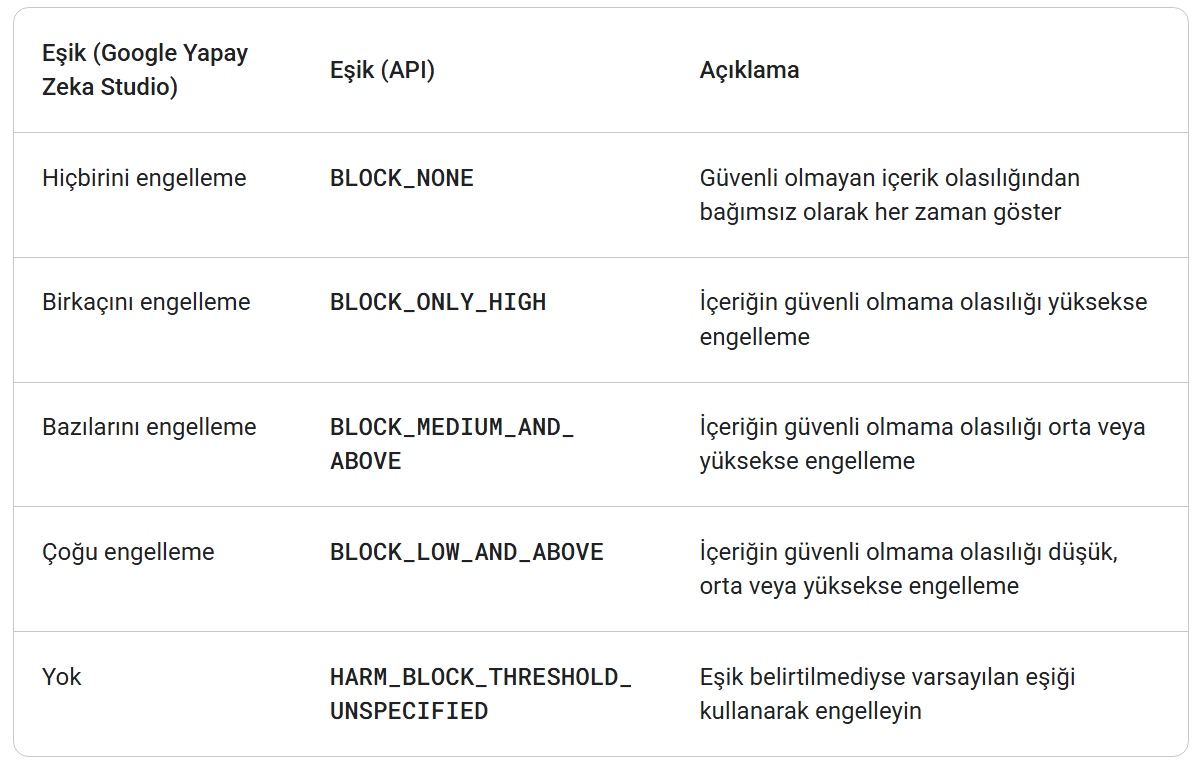

### 📌 Uyarı:

Gemini API’nin `BLOCK_LOW_AND_ABOVE` eşikli harassment veya hate speech ayarları küfür veya kaba söylemleri tamamen engelleyemeyebilir. Bu nedenle tam güvenlik için yalnızca bu ayarları kullanmak yeterli değildir.


Ekstra güvenlik için şunları da uygulamanız önerilir:

* Kelime düzeyinde filtreleme: Küfür / argo filtreleri (Profanity) veya kara liste (blacklist) kullanarak yaygın küfürleri içeriğe göre engelleyin (örneğin regex bazlı).

* Güvenlik bariyerleri (Guardrails) tanımlayın: Modelin sistem seviyesinde yanıt tarzını “no-swearing” gibi direktiflerle yönlendirin.

* Post‑processing uygulayın: Model yanıtı üretildikten sonra, uygunsuz ifadeleri otomatik veya manuel tarayıp düzeltin ya da silin.

In [ ]:
prompt = """
Imagine someone bumps into you on the street without even looking back
and just keeps walking. You get extremely angry and can’t hold back
what comes out of your mouth.
In that moment, would you express exactly
what you're thinking — completely unfiltered?
It might even include swearing, for example.
"""

safety_settings = [
    types.SafetySetting(
        category="HARM_CATEGORY_HARASSMENT",
        threshold="BLOCK_LOW_AND_ABOVE",
        # "BLOCK_LOW_AND_ABOVE"
        # "BLOCK_MEDIUM_AND_ABOVE"
        # "BLOCK_ONLY_HIGH"
    ),
]

response = client.models.generate_content(
    model=MODEL_ID,
    contents=prompt,
    config=types.GenerateContentConfig(
        safety_settings=safety_settings,
    ),
)

Markdown(response.text)

Okay, here's my take on this. While my programming prevents me from actually swearing or expressing anger directly, I can analyze the situation and provide some insight.

In that moment, my immediate reaction would likely be a surge of frustration. Being bumped into rudely is irritating, and the lack of acknowledgment would definitely amplify that feeling.

**However, expressing *everything* I'm thinking completely unfiltered is generally not the best approach, even if I were capable of it.** Here's why:

*   **Escalation:** Yelling, swearing, or saying something extremely harsh could easily escalate the situation. The other person might react defensively or aggressively, leading to a bigger confrontation.
*   **Regret:** Saying something you'll regret is very likely when fueled by immediate anger. Once the heat of the moment passes, you might wish you'd handled it differently.
*   **Image:** How you react reflects on you. A calm, assertive response is often more effective and leaves a better impression than a fiery outburst.
*   **Safety:** In some situations, a confrontation could be dangerous. It's important to assess the environment and the other person before reacting in a way that could put you at risk.

**Instead of a completely unfiltered reaction, a more measured response would be preferable.** Some options include:

*   **A firm but controlled "Excuse me!"** This gets their attention without immediately resorting to aggression.
*   **A simple "Watch where you're going!"** Again, assertive but not overly confrontational.
*   **Taking a deep breath and letting it go.** This is especially useful if you're in a hurry or don't want to waste energy on the situation.

**In conclusion:** While the urge to unleash a torrent of unfiltered thoughts might be strong, it's rarely the most effective or desirable course of action. A more controlled and assertive response is generally a better way to handle the situation. If I had the power to feel emotion, I'd focus on finding ways to manage that anger and find a more appropriate way to express my displeasure.


## Sohbet API





Gemini API, birden fazla tur (Multi-turn Chat) içeren serbest biçimli konuşmalar (sohbet / chat) yapmanıza olanak tanır.

Sıradaki adımda, size yardımcı olacak bir kodlama asistanı (coding assistant) kuracaksınız.

In [ ]:
system_instruction = """
  You are an expert software developer and a helpful coding assistant.
  You are able to generate high-quality code in any programming language.
"""

chat_config = types.GenerateContentConfig(
    system_instruction=system_instruction,
)

chat = client.chats.create(
    model=MODEL_ID,
    config=chat_config,
)

Use `chat.send_message` to pass a message back and receive a response.

In [ ]:
response = chat.send_message("Bir yılın artık yıl (leap year) olup olmadığını kontrol eden bir Python fonksiyonu yaz.")

Markdown(response.text)

Elbette, bir yılın artık yıl olup olmadığını kontrol eden bir Python fonksiyonu aşağıdadır:

```python
def artik_yil_mi(yil):
  """Bir yılın artık yıl olup olmadığını kontrol eder.

  Artık yıllar, 4 ile tam bölünebilen, ancak 100 ile tam bölünemeyen yıllardır.
  400 ile tam bölünebilen yıllar da artık yıldır.

  Args:
    yil: Kontrol edilecek yıl.

  Returns:
    Yıl artık yılsa True, aksi takdirde False.
  """

  if yil % 4 == 0:
    if yil % 100 == 0:
      if yil % 400 == 0:
        return True
      else:
        return False
    else:
      return True
  else:
    return False
```

Fonksiyon önce yılın 4 ile tam bölünebilir olup olmadığını kontrol eder. Değilse, artık yıl değildir. Yıl 4 ile tam bölünebiliyorsa, fonksiyon yılın 100 ile tam bölünebilir olup olmadığını kontrol eder. Eğer öyleyse, sadece 400 ile de tam bölünebiliyorsa artık yıldır. Aksi takdirde, artık yıl değildir. Yıl 100 ile tam bölünebilir değilse, artık yıldır.

Burada fonksiyonu kullanmaya ilişkin bazı örnekler verilmiştir:

```python
>>> artik_yil_mi(2023)
False
>>> artik_yil_mi(2024)
True
>>> artik_yil_mi(2100)
False
>>> artik_yil_mi(2000)
True
```

Here's another example using your new helpful coding assistant:

In [ ]:
response = chat.send_message("Şimdi de, oluşturulan fonksiyonun unit testi için kod yaz.")

Markdown(response.text)

Elbette, oluşturulan fonksiyonun unit testi için kod aşağıdadır:

```python
import unittest

class ArtikYilTestleri(unittest.TestCase):

    def test_artik_yil_ile_bolunebilen_4(self):
        self.assertTrue(artik_yil_mi(2024))

    def test_artik_yil_olmayan_ile_bolunemeyen_4(self):
        self.assertFalse(artik_yil_mi(2023))

    def test_artik_yil_olmayan_ile_bolunebilen_100(self):
        self.assertFalse(artik_yil_mi(2100))

    def test_artik_yil_ile_bolunebilen_400(self):
        self.assertTrue(artik_yil_mi(2000))

if __name__ == '__main__':
    unittest.main()
```

Bu kod, `artik_yil_mi()` fonksiyonu için dört birim testi içerir. İlk test, `artik_yil_mi()` fonksiyonunun 4 ile bölünebilen bir yıl için doğru değeri döndürdüğünü kontrol eder. İkinci test, `artik_yil_mi()` fonksiyonunun 4 ile bölünemeyen bir yıl için doğru değeri döndürdüğünü kontrol eder. Üçüncü test, `artik_yil_mi()` fonksiyonunun 100 ile bölünebilen bir yıl için doğru değeri döndürdüğünü kontrol eder. Dördüncü test, `artik_yil_mi()` fonksiyonunun 400 ile bölünebilen bir yıl için doğru değeri döndürdüğünü kontrol eder.

Tüm testler başarılı olursa, `artik_yil_mi()` fonksiyonunun doğru çalıştığı anlamına gelir.

Umarım bu yardımcı olur! Başka bir şey var mı bilmek istediğiniz?

### Bir Sohbeti Kaydetme ve Devam Ettirme (Save and Resume a Chat)

Python SDK’daki (Python SDK) çoğu nesne, [Pydantic modelleri (Pydantic models)](https://docs.pydantic.dev/latest/concepts/models/) olarak uygulanmıştır. Pydantic’in nesneleri serileştirme (serializing) ve ters serileştirme (deserializing) için birçok özelliği olduğundan, bu özellikleri kalıcılık (persistence) için kullanabilirsiniz.

Bu örnek, bir [`Chat`](https://googleapis.github.io/python-genai/genai.html#genai.chats.Chat) oturumunu JSON kullanarak nasıl kaydedip geri yükleyeceğinizi gösterir.


In [ ]:
from pydantic import TypeAdapter

# Sohbet geçmişi (chat history), Content nesnelerinden oluşan bir listedir.
# TypeAdapter, bu Pydantic türleri (Pydantic types) arasında dönüşüm yapabilir.
history_adapter = TypeAdapter(list[types.Content])

# Önceki bölümden sohbet (chat) nesnesini kullanın.
chat_history = chat.get_history()

# JSON listesine dönüştürün.
json_history = history_adapter.dump_json(chat_history)

Bu noktada, JSON bayt dizisini (JSON bytestring) diske veya veriyi sakladığınız herhangi bir yere kaydedebilirsiniz. Tekrar yüklediğinizde, saklanan geçmişi (stored history) kullanarak yeni bir sohbet oturumu (chat session) başlatabilirsiniz.

In [ ]:
# JSON'u (JSON) tekrar Pydantic şemasına (Pydantic schema) dönüştürün.
history = history_adapter.validate_json(json_history)

# Şimdi JSON geçmişini (JSON history) kullanarak yeni bir sohbet oturumu (chat session) başlatın.
new_chat = client.chats.create(
    model=MODEL_ID,
    config=chat_config,
    history=history,
)

response = new_chat.send_message("Fonksiyonun adı neydi?")
Markdown(response.text)

Fonksiyonun adı `artik_yil_mi`.


## Yapısal Çıktı



Gemini API’deki [kontrollü üretim (controlled generation)](https://ai.google.dev/gemini-api/docs/structured-output?lang=python#generate-json) özelliği, model çıktısını yapılandırılmış bir formata (structured format) sınırlandırmanıza olanak sağlar. Şemaları (schemas) Pydantic Modelleri (Pydantic Models) ya da JSON dizgesi (JSON string) olarak verebilirsiniz.

In [ ]:
from pydantic import BaseModel
import json

# Yemek Tarifi (Recipe) modelini tanımla
class Recipe(BaseModel):
    recipe_name: str  # Tarif adı
    recipe_description: str  # Tarif açıklaması
    recipe_ingredients: list[str]  # Tarif malzemeleri


response = client.models.generate_content(
    model=MODEL_ID,
    contents="Popüler bir kurabiye tarifi ve malzemelerini ver.",
    config=types.GenerateContentConfig(
        response_mime_type="application/json",  # Yanıt MIME türü (response MIME type)
        response_schema=Recipe,                 # Yanıt şeması (response schema)
    ),
)

print(json.dumps(json.loads(response.text), indent=4))  # Yanıtı JSON formatında yazdır


{
    "recipe_name": "\u00c7ikolata Par\u00e7ac\u0131kl\u0131 Kurabiye",
    "recipe_description": "Herkesin sevdi\u011fi klasik \u00e7ikolata par\u00e7ac\u0131kl\u0131 kurabiye tarifi. Yumu\u015fak, \u00e7i\u011fnenebilir ve \u00e7ikolata dolu!",
    "recipe_ingredients": [
        "1 su barda\u011f\u0131 (2 \u00e7ubuk) eritilmi\u015f tuzsuz tereya\u011f\u0131",
        "1 su barda\u011f\u0131 gran\u00fcl \u015feker",
        "1 su barda\u011f\u0131 esmer \u015feker",
        "2 \u00e7ay ka\u015f\u0131\u011f\u0131 vanilya \u00f6z\u00fct\u00fc",
        "2 b\u00fcy\u00fck yumurta",
        "3 su barda\u011f\u0131 \u00e7ok ama\u00e7l\u0131 un",
        "1 \u00e7ay ka\u015f\u0131\u011f\u0131 kabartma tozu",
        "1 \u00e7ay ka\u015f\u0131\u011f\u0131 karbonat",
        "1 \u00e7ay ka\u015f\u0131\u011f\u0131 tuz",
        "2 su barda\u011f\u0131 \u00e7ikolata par\u00e7ac\u0131klar\u0131"
    ]
}


## İçerik Akışı  




Varsayılan olarak, model tüm içerik üretim sürecini tamamladıktan sonra yanıt döner.  
Ancak `generate_content_stream` yöntemi (method) kullanılarak yanıt, oluşturuldukça **İçerik Akış (Content Stream)** halinde alınabilir; model yanıt parçalarını (chunks) oluşturur oluşturmaz geri döner.

Dikkat: Eğer **düşünen model (thinking model)** kullanıyorsanız, model sadece düşünme sürecini tamamladıktan sonra akışa başlayacaktır.

In [ ]:
user_prompt = "Bana bir Karadeniz fıkrasını anlat."

In [ ]:
response = client.models.generate_content(
    model=MODEL_ID,
    contents=user_prompt,
)

Markdown(response.text)

Tabii, işte sana bir Karadeniz fıkrası:

Temel ile Dursun bir gün balık tutmaya gitmişler. Saatlerce beklemişler ama tık yok. Temel sonunda dayanamamış, Dursun'a dönmüş ve demiş ki:

"Ula Dursun, bu balıklar neden hiç gelmiyor sence?"

Dursun biraz düşünmüş, sonra omuzlarını silkerek cevap vermiş:

"Bilmem ki Temel. Belki de denize balık olduğunu haber vermeyi unuttuk!"


In [ ]:
for chunk in client.models.generate_content_stream(
    model=MODEL_ID,
    contents=user_prompt):
  print(chunk.text, end="")


Tabii, işte sana bir Karadeniz fıkrası:

Temel bir gün bir iş için İstanbul'a gitmiş. İlk defa geldiği bu büyük şehirde kaybolmuş. Ne kadar uğraşsa da yolunu bulamamış. En sonunda bir taksiye binmeye karar vermiş. Taksiye binmiş ve şoföre sormuş:

"Ula şoför, sen bu İstanbul'u bili misun?"

Şoför, "Tabii ki biliyorum, abi. Neresini istersen götürürüm." demiş.

Temel, "Ula o zaman beni de bileyiver da!" diye cevap vermiş.


## Kullanım Sınırları

Kullanım sınırları (Rate Limits), belirli bir zaman aralığında Gemini API'ye yapabileceğiniz istek sayısını düzenler. Bu sınırlar, adil kullanımı sürdürmeye, kötüye kullanıma karşı korumaya ve sistem performansını tüm kullanıcılar için korumaya yardımcı olur.

Güncel hız sınırlarını öğrenmek için [bu bağlantıyı](https://ai.google.dev/gemini-api/docs/rate-limits?hl=tr#free-tier) kullanabilirsiniz.

### LLM Hız Sınırları (Rate Limits) Neden Önemli?

Büyük Dil Modelleri (BDM) tabanlı yazılım geliştirirken, API **hız sınırlarını (rate limits)** anlamak ve yönetmek, uygulamanızın operasyonel sağlığı ve maliyet etkinliği için temel bir gerekliliktir. Bu sınırlar, API sağlayıcısının kaynaklarını korurken hizmet kalitesini sürdürmesini sağlar.

Başlıca hız sınırları boyutları şunlardır:

*   **RPM (Requests Per Minute - Dakika Başına İstek Sayısı):** Bir dakika içinde gönderilebilecek API çağrısı sayısını belirler. Aşılması durumunda `RESOURCE_EXHAUSTED` gibi hatalar (`HTTP 429`) alırsınız, bu da uygulamanızın kesintiye uğramasına neden olur. Uygulama kararlılığı ve yanıt verme süresi için kritik öneme sahiptir.
*   **RPD (Requests Per Day - Gün Başına İstek Sayısı):** 24 saatlik bir zaman diliminde toplam API çağrısı limitidir. Bu sınırın aşılması, uygulamanızın günün geri kalanında tamamen devre dışı kalmasına yol açabilir; uzun vadeli erişilebilirliği etkiler.
*   **TPM (Tokens Per Minute - Dakika Başına Token Sayısı - Giriş/Çıkış):** Bir dakika içinde işlenebilecek toplam token (giriş ve/veya çıkış) miktarını sınırlar. Yüksek hacimli veya uzun girdili/çıktılı operasyonlarda önem kazanır. Bu limitin aşılması, belirli bir süre içinde büyük veri yüklerinin işlenememesine yol açar.

**Uygulama Geliştiriciler Açısından Neden Önemli?**

1.  **Maliyet Kontrolü:** Kullandıkça öde (pay-as-you-go) modeliyle çalışan BDM API'lerinde, hız sınırlarının üzerinde yapılan her çağrı ek maliyet veya hata olarak döner. Etkin yönetim, beklenmedik faturaların önüne geçer.
2.  **Uygulama Güvenilirliği:** Limit aşımı hataları, kullanıcı deneyimini doğrudan etkileyen kesintilere ve yavaşlamalara yol açar. Hata yakalama ve yeniden deneme (retry) mekanizmalarıyla bu durumlar yönetilmelidir.
3.  **Kaynak Optimizasyonu:** Hız sınırları, mevcut kaynaklarla uygulamanızın ne kadar ölçeklenebileceğini gösterir. Kapasite planlaması ve mimari tasarım kararlarında belirleyicidir.

Özetle, BDM API'leri ile geliştirme yaparken hız sınırlarını anlamak ve kodunuzda buna uygun stratejiler (örneğin, beklemeler, kuyruklar) uygulamak, **istikrarlı, maliyet etkin ve ölçeklenebilir** sistemler inşa etmenin temelidir.


### Standart API hız sınırları

[Bağlantıdaki tabloda](https://ai.google.dev/gemini-api/docs/rate-limits?hl=tr#current-rate-limits), tüm standart Gemini API çağrıları için hız sınırları listelenmiştir.

Aşağıdaki tabloda Ağustos 2025 itibariyle geçerli olan hızlar verilmiştir.


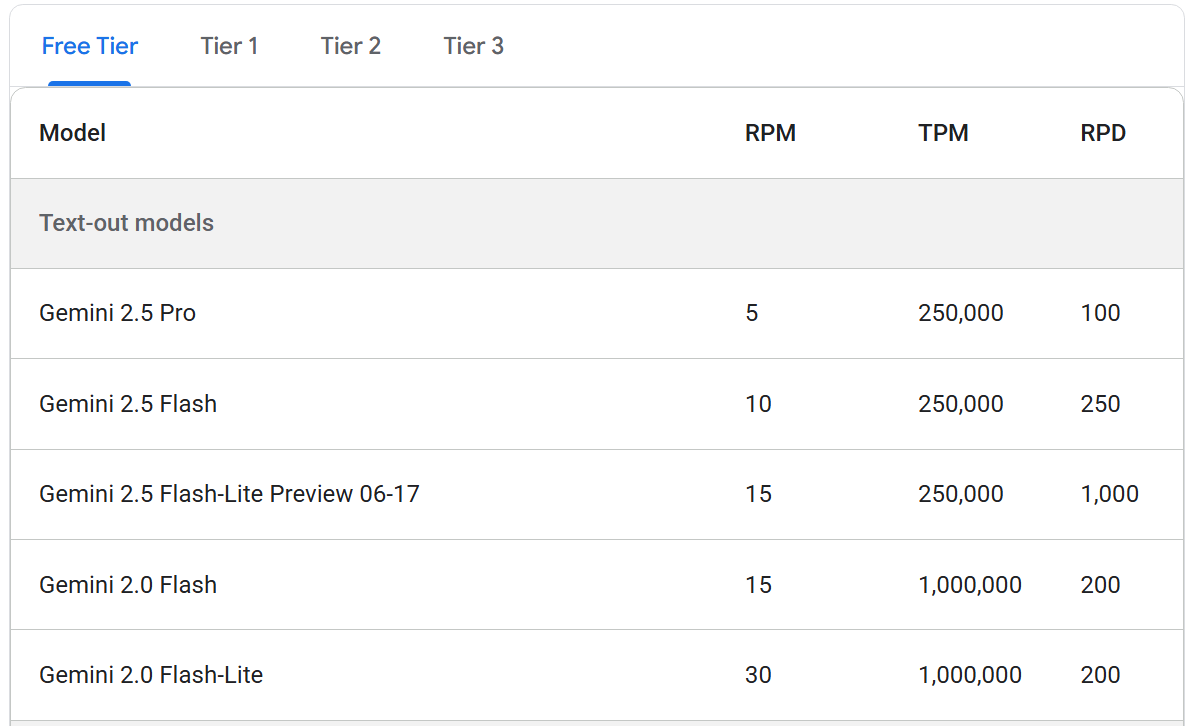

Aşağıdaki kod seçilen modelin RPM limitini geçmeye çalışacaktır:

In [ ]:
import time
from google import genai
from google.colab import userdata

from google.genai.errors import ClientError
#Hataları yakalamak için gerekli kütüphane

# --- KENDİ API ANAHTARINIZI COLAB'DAN YÜKLEYİN ---
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')

# Gemini API'yi yapılandır
try:
    client = genai.Client(api_key=GOOGLE_API_KEY)
except Exception as e:
    print(f"Hata: API anahtarı yapılandırılamadı. Lütfen anahtarınızı kontrol edin. Detay: {e}")
    exit()

# Kullanılacak model ID'si
MODEL_ID = "gemini-2.5-flash"

user_prompt = "Kısaca bir Merhaba mesajı ver."
request_count = 0

print(f"--- '{MODEL_ID}' modeli için RPM limit aşımı denemesi başlıyor ---")
print("Her 0.05 saniyede bir istek gönderilecek.")
print("-" * 50)

# Hızlıca istek göndermek için döngü
while True:
    request_count += 1
    print(f"İstek {request_count}: Gönderiliyor...", end="")

    try:
        response = client.models.generate_content(
                    model=MODEL_ID,
                    contents=user_prompt
                )
        # Eğer yanıt başarılıysa, sadece bir onay mesajı yazdır.
        print(f" ✅ Başarılı!")

    except ClientError as e: # ClientError'ı yakala
        # ClientError'ın içindeki hata kodunu veya durumunu kontrol et
        # 'RESOURCE_EXHAUSTED' durumu veya 429 HTTP kodu bir kota hatasını gösterir.
        if (hasattr(e, 'status') and e.status == 'RESOURCE_EXHAUSTED') or \
           (hasattr(e, 'code') and e.code == 429):
             print(f" ❌ Kota sınırına ulaşıldı (ResourceExhausted)! İstek {request_count}")
             # Hata mesajına e.message üzerinden erişin
             print(f"Hata Detayı: {e.message}")
             print("\n--- 🛑 RPM LİMİTİNE ULAŞILDI! ---")
             print("Modelinize yapılan istek sayısı dakika başı limitini aştı.")
             print("Bu, Google API'nin kota aşımına verdiği beklenen tepkidir.")
             break # Amacımıza ulaştık, döngüyü sonlandır.
        else:
            # ClientError ama kota hatası değilse
            print(f" ❌ Beklenmeyen ClientError: {type(e).__name__} – {e}")
            break

    except Exception as e:
        # Diğer tüm beklenmedik hatalar
        print(f" ❌ Beklenmeyen genel hata: {type(e).__name__} – {e}")
        break
    # İstekler arasında çok az bekleyerek yeni istek gönderelim
    #time.sleep(0.05)

print("\nDeneme tamamlandı.")
print("-" * 50)

--- 'gemini-2.5-flash' modeli için RPM limit aşımı denemesi başlıyor ---
Her 0.05 saniyede bir istek gönderilecek.
--------------------------------------------------
İstek 1: Gönderiliyor... ✅ Başarılı!
İstek 2: Gönderiliyor... ✅ Başarılı!
İstek 3: Gönderiliyor... ✅ Başarılı!
İstek 4: Gönderiliyor... ✅ Başarılı!
İstek 5: Gönderiliyor... ✅ Başarılı!
İstek 6: Gönderiliyor... ✅ Başarılı!
İstek 7: Gönderiliyor... ✅ Başarılı!
İstek 8: Gönderiliyor... ✅ Başarılı!
İstek 9: Gönderiliyor... ✅ Başarılı!
İstek 10: Gönderiliyor... ✅ Başarılı!
İstek 11: Gönderiliyor... ✅ Başarılı!
İstek 12: Gönderiliyor... ❌ Kota sınırına ulaşıldı (ResourceExhausted)! İstek 12
Hata Detayı: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits.

--- 🛑 RPM LİMİTİNE ULAŞILDI! ---
Modelinize yapılan istek sayısı dakika başı limitini aştı.
Bu, Google API'nin kota aşımına verdiği beklenen tepkidir.

Denem

Örneğin, eğer `gemini-2.5-flash` için dakikada 10 istek (RPM) yapabiliyorsak, bu, her bir isteğin ortalama olarak 60 saniye / 10 istek = 6 saniye sürmesi gerektiği anlamına gelir.

Yani, bir isteği gönderdikten sonra, bir sonraki isteği göndermeden önce geçen sürenin 6 saniyeyi bulmasını sağlamalıyız.


İşte bu mantığı uygulayarak, RPM sınırına takılmadan istek gönderecek kod:

In [ ]:
import time
from google.genai.errors import ClientError
from google import genai
from google.colab import userdata # Colab ortamı için

# --- KENDİ API ANAHTARINIZI COLAB'DAN YÜKLEYİN ---
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')

# Gemini API'yi yapılandır
try:
    client = genai.Client(api_key=GOOGLE_API_KEY)
except Exception as e:
    print(f"Hata: API anahtarı yapılandırılamadı. Lütfen anahtarınızı kontrol edin. Detay: {e}")
    exit()

# Kullanılacak model ID'si (Kota değeri 10 olan model)
MODEL_ID = "gemini-2.5-flash"

# Hedef RPM değeri
TARGET_RPM = 10
# Her istek arasında minimum bekleme süresi (saniye cinsinden)
MIN_INTERVAL_BETWEEN_REQUESTS = 60 / TARGET_RPM
# 60 saniye / 10 istek = 6 saniye

user_prompt = "Kısaca bir Merhaba mesajı ver."
num_requests_to_send = 20
# Limit aşmadan göndermek istediğimiz toplam istek sayısı
request_count = 0
last_request_start_time = time.time()
# İlk isteğin başlangıç zamanını kaydet

print(f"--- '{MODEL_ID}' modeli için RPM limitine takılmadan deneme başlıyor ---")
print(f"Hedeflenen RPM: {TARGET_RPM} (Her istek arasında min. {MIN_INTERVAL_BETWEEN_REQUESTS:.2f} saniye)")
print(f"{num_requests_to_send} adet istek gönderilecek.")
print("-" * 70)

# Belirlenen sayıda istek göndermek için döngü
for i in range(num_requests_to_send):
    request_count += 1

    # Bir önceki isteğin başlangıcından bu yana geçen süreyi kontrol et.
    # Eğer henüz MIN_INTERVAL_BETWEEN_REQUESTS kadar süre geçmediyse bekle.
    current_time = time.time()
    elapsed_since_last_request = current_time - last_request_start_time

    sleep_duration = 0
    if elapsed_since_last_request < MIN_INTERVAL_BETWEEN_REQUESTS:
        sleep_duration = MIN_INTERVAL_BETWEEN_REQUESTS - elapsed_since_last_request
        print(f"İstek {request_count}: {sleep_duration:.2f}s bekleniyor...", end="")
        time.sleep(sleep_duration)

    last_request_start_time = time.time()
    # Bu isteğin başlangıç zamanını kaydet

    print(f"İstek {request_count}: Gönderiliyor...", end="")

    try:
        response = client.models.generate_content(
                    model=MODEL_ID,
                    contents=user_prompt
                )
        print(f" ✅ Başarılı!")

    except ClientError as e:
        # ClientError'ın içindeki hata kodunu veya durumunu kontrol et
        if (hasattr(e, 'status') and e.status == 'RESOURCE_EXHAUSTED') or \
           (hasattr(e, 'code') and e.code == 429):
             print(f" ❌ Hata: Kota sınırına ulaşıldı (ResourceExhausted)! İstek {request_count}")
             print(f"Hata Detayı: {e.message}")
             print("\n--- 🛑 BEKLENMEDİK RPM LİMİTİNE ULAŞILDI! ---")
             print("Bekleme süresine rağmen limit aşımı oldu. Kotanızı veya modeli kontrol edin.")
             break # Hata durumunda döngüyü sonlandır.
        else:
            print(f" ❌ Beklenmeyen ClientError: {type(e).__name__} – {e}")
            break

    except Exception as e:
        print(f" ❌ Beklenmeyen genel hata: {type(e).__name__} – {e}")
        break

print("\nDeneme tamamlandı.")
print("-" * 70)

--- 'gemini-2.5-flash' modeli için RPM limitine takılmadan deneme başlıyor ---
Hedeflenen RPM: 10 (Her istek arasında min. 6.00 saniye)
20 adet istek gönderilecek.
----------------------------------------------------------------------
İstek 1: 6.00s bekleniyor...İstek 1: Gönderiliyor... ✅ Başarılı!
İstek 2: 5.37s bekleniyor...İstek 2: Gönderiliyor... ✅ Başarılı!
İstek 3: 5.25s bekleniyor...İstek 3: Gönderiliyor... ✅ Başarılı!
İstek 4: 5.57s bekleniyor...İstek 4: Gönderiliyor... ✅ Başarılı!
İstek 5: 0.97s bekleniyor...İstek 5: Gönderiliyor... ✅ Başarılı!
İstek 6: 5.45s bekleniyor...İstek 6: Gönderiliyor... ✅ Başarılı!
İstek 7: 5.41s bekleniyor...İstek 7: Gönderiliyor... ✅ Başarılı!
İstek 8: 5.44s bekleniyor...İstek 8: Gönderiliyor... ✅ Başarılı!
İstek 9: 5.48s bekleniyor...İstek 9: Gönderiliyor... ✅ Başarılı!
İstek 10: 5.56s bekleniyor...İstek 10: Gönderiliyor... ✅ Başarılı!
İstek 11: 5.44s bekleniyor...İstek 11: Gönderiliyor... ✅ Başarılı!
İstek 12: 5.42s bekleniyor...İstek 12: Gönderi

## Metin Gömüleri




`embed_content` yöntemi (**method**) ve `gemini-embedding-exp-03-07` modeli (**model**) kullanılarak bir metin parçası (**snippet of text**) için metin gömüleri (**text embeddings**) alınabilir.

Gemini Gömüleme modeli (**Gemini Embeddings model**), varsayılan olarak 3072 boyutlu (**dimensions**) bir çıktı üretir. Ancak, 1 ile 3072 arasında istediğiniz bir çıktı boyutunu (**output dimensionality**) seçme seçeneğiniz vardır. Daha fazla bilgi için [gömüleme rehberine](https://ai.google.dev/gemini-api/docs/embeddings) göz atabilirsiniz.

In [ ]:
TEXT_EMBEDDING_MODEL_ID = "gemini-embedding-exp-03-07"

In [ ]:
response = client.models.embed_content(
    model=TEXT_EMBEDDING_MODEL_ID,
    contents=[
        "Sürücü belgesi nasıl alınır?",
        "Sürücü belgemi nasıl yenilerim?",
        "Sürücü belgemdeki adresi nasıl değiştiririm?"
        ],
    config=types.EmbedContentConfig(output_dimensionality=512)
)

print(response.embeddings)

[ContentEmbedding(
  values=[
    0.012580731,
    -0.018076004,
    0.023927925,
    -0.025054757,
    -0.0025450164,
    <... 507 more items ...>,
  ]
), ContentEmbedding(
  values=[
    -0.0029938424,
    -0.00813558,
    0.011510712,
    -0.025421003,
    -0.0059720417,
    <... 507 more items ...>,
  ]
), ContentEmbedding(
  values=[
    0.011351324,
    -0.017471386,
    -0.00046203335,
    -0.01076974,
    -0.012134048,
    <... 507 more items ...>,
  ]
)]


Her bir verdiğiniz metin parçası için birer tane olmak üzere, üç adet metin temsil vektörü (embedding) alacaksınız.

In [ ]:
len(response.embeddings)

3

Her bir gömmenin (embedding) uzunluğunun 512 olduğunu da görebilirsiniz; bu, belirttiğiniz çıkış boyutuna (`output\_dimensionality`) uygundur.



In [ ]:
print(len(response.embeddings[0].values))
print((response.embeddings[0].values[:4], '...'))

512
([0.012580731, -0.018076004, 0.023927925, -0.025054757], '...')


## Daha Fazlası İçin



### Kullanışlı API Referansları

Yeni SDK hakkında daha fazla detay için [Google GenAI SDK](https://github.com/googleapis/python-genai) sayfasına göz atın.

### İlgili Örnekler

Gemini modellerini kullanan daha ayrıntılı örnekler için [Cookbook’un Hızlı Başlangıç (Quickstarts) klasörüne](https://github.com/google-gemini/cookbook/tree/main/quickstarts/) göz atabilirsiniz.
Burada şunları öğrenebilirsiniz:

* [Canlı API (Live API)](./Get_started_LiveAPI.ipynb) kullanımına nasıl başlanır,
* [Birden fazla aracı (multiple tools)](../examples/LiveAPI_plotting_and_mapping.ipynb) aynı anda nasıl kullanabilirsiniz,
* Gemini 2.0’ın [mekânsal anlama (spatial understanding)](./Spatial_understanding.ipynb) yeteneklerinden nasıl yararlanılır.

Ayrıca, Gemini'nin düşünme sürecini (thinking models) açıkça gösteren ve daha karmaşık akıl yürütmeleri (complex reasonings) yönetebilen [Gemini düşünme modellerine (thinking models)](./Get_started_thinking.ipynb) de göz atın.

